In [ ]:
"""
Code accompanying the papers:

Diego Febbe, Duccio Fanelli, Timoteo Carletti, "Exploring Simplicial Complexes by wandering across the dimensions", arXiv, 2026.
Diego Febbe, Duccio Fanelli, Timoteo Carletti, "Simplicial Complexes with dimension-wise preferential attachment", arXiv, 2026.

If you use this code, please cite the above works (bibtex in README file).
"""

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.sparse as sp
from simplicial_generator_class import SimplicialComplex
from collections import Counter
from simplicial_random_walk_class import RandomWalkSimplex, RandomWalkerGraph
import time

In [2]:
def count_occurrences(lst, N, simplex):
    """
    This function counts the normalized occurrences and returns
    the simplex type of each index from 0 to N-1.

    Parameters:
        lst (list[int]): List of indices.
        N (int): Total number of elements.
        simplex: Object with attributes .nodes, .links, .triangles, .tetrahedra.

    Returns:
        tuple: (freqs, types)
            freqs: list of floats of length N with normalized occurrences.
            types: list of ints of length N
                   (0=node, 1=link, 2=triangle, 3=tetrahedron).
    """
    count = Counter(lst)
    total_elements = len(lst)


    freqs = [(count[i] / total_elements) if i in count else 0 for i in range(N)]

    num_nodes = len(simplex.nodes)
    num_links = len(simplex.links)
    num_triangles = len(simplex.triangles)

    types = []
    for i in range(N):
        if i < num_nodes:
            types.append(0)
        elif i < num_nodes + num_links:
            types.append(1)
        elif i < num_nodes + num_links + num_triangles:
            types.append(2)
        else:
            types.append(3)

    return freqs, types

In [3]:
# %%
# Usage
# Create a simplicial complex
p_1 = 1 / 3
p_2 = 1 / 3
p_3 = 1 - p_1 - p_2
kwargs = {'initialization': 'tetrahedron', 'prob_new_link': p_1,
          'prob_new_triangle': p_2, 'prob_new_tetrahedron': p_3, }
# initialization = 'tetrahedron', 'triangle', 'link', 'node'

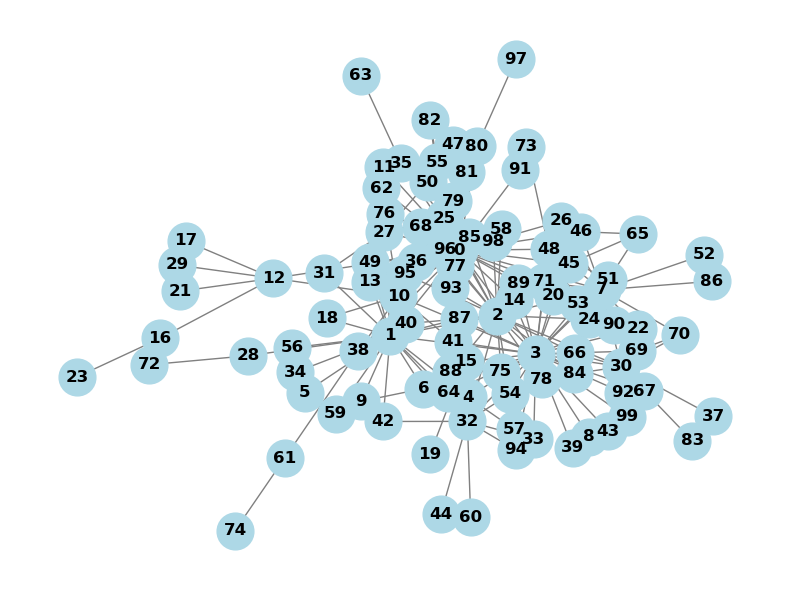

In [4]:
N = 100
N_0 = 4 if kwargs['initialization'] == 'tetrahedron' else 3 if kwargs['initialization'] == 'triangle' \
                    else 2 if kwargs['initialization'] == 'link' else 1 if kwargs['initialization'] == 'node' else 0
N_increase = N-N_0
simplex = SimplicialComplex(**kwargs)
for i in range(N_increase): 
    simplex.add_simplex()
simplex.plot_graph()

In [5]:
# Define the random_walk classes on the simplicial complex and on the graph
rws = RandomWalkSimplex(simplex, **kwargs)
rwg = RandomWalkerGraph(simplex.adjacency_matrix())

In [6]:
k = rws.degree()

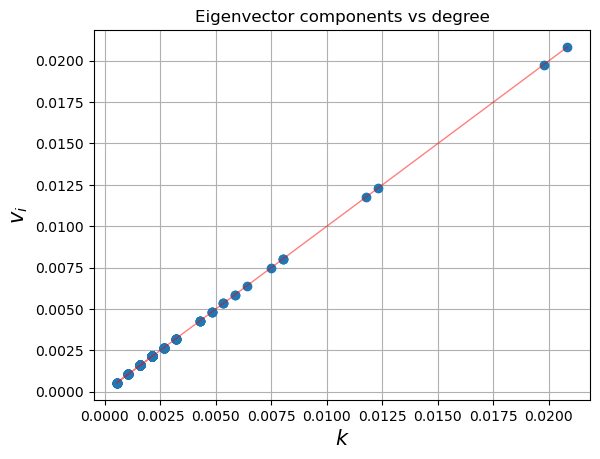

In [7]:
l, v = rws.eigenvalues_eigenvectors()
l_max = np.max(np.abs(l))
v_max = np.real(v[:, np.argmax(np.real(l))])
v_max = v_max / np.sum(v_max)
plt.plot(k, v_max, 'o')
plt.xlabel('$k$', fontsize=15)
plt.ylabel('$v_i$', fontsize=15)
plt.plot(k, k, 'r', linewidth=1, alpha=0.5)
plt.title('Eigenvector components vs degree')
plt.grid(True)
plt.show()

In [8]:
conv_time = rws.convergence_time()
print(f"Convergence time: {conv_time}")

Convergence time: 466


In [9]:
start = time.time()
n_sample = 20
n_time = 20
final_rws_indices = []
for _ in range(n_sample):
    for i in range(n_time * conv_time):
        rws.walker()
        # rwg.walker()
    rws_path = rws.path
    # rwg_path = rwg.path
    rws_indices = [elem[0] for elem in rws_path]
    final_rws_indices.append(rws_indices)
final_rws_indices = [item for sublist in final_rws_indices for item in sublist]
print(f"simulation time: {time.time() - start}")

simulation time: 5.1310133934021


In [10]:
print(rws_path)
#print(rwg_path)

IOPub data rate exceeded.
The notebook server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--NotebookApp.iopub_data_rate_limit`.

Current values:
NotebookApp.iopub_data_rate_limit=1000000.0 (bytes/sec)
NotebookApp.rate_limit_window=3.0 (secs)



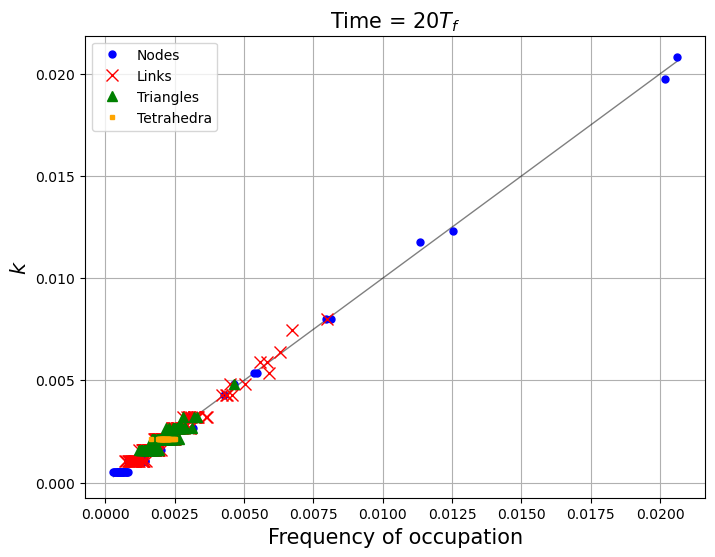

In [11]:
different_marker_flag = True

freqs, types = count_occurrences(
    final_rws_indices,
    sum(simplex.total_number_of_simplices()),
    simplex
)
if different_marker_flag:
    # types → simbols
    markers = {0: 'o', 1: 'x', 2: '^', 3: 's'}
    colors  = {0: 'blue', 1: 'red', 2: 'green', 3: 'orange'}
    labels = {0: "Nodes", 1: "Links", 2: "Triangles", 3: "Tetrahedra"}
    marker_sizes = {0: 5, 1: 8, 2: 7, 3: 3}

    plt.figure(figsize=(8, 6))
    plt.plot(freqs, freqs, 'k', linewidth=1, alpha=0.5)
    for t in range(4):
        idx = [i for i, tp in enumerate(types) if tp == t]
        plt.plot(
            [freqs[i] for i in idx],
            [k[i] for i in idx],
            markers[t],
            color=colors[t],
            label=labels[t],
            markersize=marker_sizes[t],
            linestyle="None"
        )
else:
    plt.plot(freqs, k, 'o')
    plt.plot(k, k, 'r', linewidth=1, alpha=0.5)


plt.xlabel('Frequency of occupation', fontsize=15)
plt.ylabel('$k$', fontsize=15)
plt.title(rf'Time = {n_time}$T_f$', fontsize=15)
plt.grid(True)
plt.legend()
plt.show()